In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.options.display.max_columns = None
pd.options.display.max_rows = 100
sns.set_theme(style="whitegrid")

# Cargar datos
path = "data/upn_prospectos.csv"
df = pd.read_csv(path, encoding="cp1252", low_memory=False)

# Convertir fechas
for col in ["FECHA_REGISTRO", "FECHA_PM", "FECHA_ULT_VALORACION"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Información básica
print("Dimensiones:", df.shape)
print("\nColumnas:\n", df.columns.tolist())
print("\nTipos de datos:\n")
print(df.dtypes)


C:\Users\jhuaytalla\AppData\Local\Temp\ipykernel_33864\134995342.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


Dimensiones: (11679400, 24)

Columnas:
 ['LEAD_ID', 'CAMPAÑA', 'BASE_ST', 'TIPO_ESTUDIANTE', 'CAMPUS', 'FUENTE_ORIGEN', 'CARRERA', 'FACULTAD', 'COLEGIO', 'PM', 'FECHA_REGISTRO', 'EDAD', 'AÑO_EGRESO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FECHA_PM', 'COLEGIO_TIPO', 'FECHA_ULT_VALORACION', 'RANGO_EDAD', 'RANGO_EGRESO', 'REG', 'UND', 'GENERO']

Tipos de datos:

LEAD_ID                            str
CAMPAÑA                            str
BASE_ST                            str
TIPO_ESTUDIANTE                    str
CAMPUS                             str
FUENTE_ORIGEN                      str
CARRERA                            str
FACULTAD                           str
COLEGIO                            str
PM                               int64
FECHA_REGISTRO          datetime64[us]
EDAD                             int64
AÑO_EGRESO                     float64
DEPARTAMENTO                       str
PROVINCIA                          str
DISTRITO                           str
FECHA_PM   

In [6]:
# Primeras filas
print("\nPrimeras 5 filas:")
df.head(100)



Primeras 5 filas:


,LEAD_ID,CAMPAÑA,BASE_ST,TIPO_ESTUDIANTE,CAMPUS,FUENTE_ORIGEN,CARRERA,FACULTAD,COLEGIO,PM,FECHA_REGISTRO,EDAD,AÑO_EGRESO,DEPARTAMENTO,PROVINCIA,DISTRITO,FECHA_PM,COLEGIO_TIPO,FECHA_ULT_VALORACION,RANGO_EDAD,RANGO_EGRESO,REG,UND,GENERO
0,b4bf0321-d68b-f011-b4cc-6045bd39511e,2026-01,RECICLADOS PARA MKT DIRECTO,Nuevo,OLIVOS,Reciclado,COMUNICACION Y DISEÑO GRAFICO,FACULTAD DE COMUNICACIONES,3098 CESAR VALLEJO,0,2025-09-01 12:00:00,0,2022.0,LIMA,LIMA,ANCON,NaT,Publica,NaT,[Otros],Egresos 2022,1,PG,Masculino
1,b4bf25c6-068c-f011-b4cc-000d3a8857b7,2026-01,RECICLADOS PARA MKT DIRECTO,Nuevo,OLIVOS,Reciclado,ADMINISTRACION,FACULTAD DE NEGOCIOS,SIN DATO,0,2025-09-01 12:00:00,43,0.0,PIURA,PIURA,PIURA,NaT,SIN DATO,NaT,[>40],SIN DATO,1,WA,SIN DATO
2,b4bf4946-0489-f011-b4cb-6045bd393fce,2026-01,RECICLADOS PARA MKT DIRECTO,Nuevo,OLIVOS,Reciclado,CONTABILIDAD Y FINANZAS,FACULTAD DE NEGOCIOS,SIN DATO,0,2025-09-01 12:00:00,31,0.0,LIMA,LIMA,LOS OLIVOS,NaT,SIN DATO,NaT,[31 - 35],SIN DATO,1,WA,Masculino
3,b4bf5574-d58b-f011-b4cb-000d3ac1aab3,2026-01,RECICLADOS PARA MKT DIRECTO,Nuevo,COMAS,Reciclado,CONTABILIDAD Y FINANZAS,FACULTAD DE NEGOCIOS,5172 HIJOS DE LUYA,0,2025-09-01 12:00:00,0,0.0,LIMA,LIMA,PUENTE PIEDRA,NaT,Publica,NaT,[Otros],SIN DATO,1,PG,SIN DATO
4,b4bf5b5a-f1bc-f011-bbd3-00224837e424,2026-01,COLEGIOS,Nuevo,SUR,Colegios,DERECHO Y CIENCIAS POLITICAS,FACULTAD DE DERECHO,20874,0,2025-11-08 12:00:00,17,2025.0,LIMA,CAÑETE,SAN VICENTE DE CAÑETE,NaT,Publica,2025-12-11 12:00:00,[15 - 17],Egresos 2025,1,PG,SIN DATO
5,b4bf5e87-fc8a-f011-b4cb-6045bd393fce,2026-01,RECICLADOS PARA MKT DIRECTO,Nuevo,CAX,Reciclado,INGENIERIA DE SISTEMAS COMPUTACIONALES,FACULTAD DE INGENIERÍA,SAN JUAN,0,2025-09-01 12:00:00,0,0.0,CAJAMARCA,CHOTA,CHOTA,NaT,Publica,NaT,[Otros],SIN DATO,1,PG,Femenino
6,b4bf6138-84af-ef11-a72e-002248dfb440,2026-01,COLEGIOS,Nuevo,SUR,Colegios,ENFERMERIA,FACULTAD DE SALUD,JUAN GUERRERO QUIMPER,0,2025-09-01 12:00:00,0,2025.0,LIMA,LIMA,VILLA MARIA DEL TRIUNFO,NaT,Publica,2026-02-06 12:00:00,[Otros],Egresos 2025,1,PG,NaN
7,b4bf6ade-b38b-f011-b4cb-000d3ac1f548,2026-01,RECICLADOS PARA MKT DIRECTO,Nuevo,BREÑA,Reciclado,ADMINISTRACION BANCARIA Y FINANCIERA,FACULTAD DE NEGOCIOS,SIN DATO,0,2025-09-01 12:00:00,26,0.0,LIMA,LIMA,LIMA,NaT,SIN DATO,NaT,[26 - 30],SIN DATO,1,PG,SIN DATO
8,b4bf71ff-738b-f011-b4cb-000d3ac1aab3,2026-01,RECICLADOS,Nuevo,OLIVOS,Reciclado,SIN DATO,SIN DATO,SIN DATO,0,2025-09-01 12:00:00,28,0.0,CAJAMARCA,CAJAMARCA,CAJAMARCA,NaT,SIN DATO,NaT,[26 - 30],SIN DATO,1,PG,SIN DATO
9,b4bf747c-4a33-ef11-8e4e-002248df62f9,2026-01,COLEGIOS,Nuevo,OLIVOS,Colegios,COMUNICACION Y MARKETING DIGITAL,FACULTAD DE COMUNICACIONES,2078 NUESTRA SEÑORA DE LOURDES,1,2025-09-01 12:00:00,16,2025.0,LIMA,LIMA,CARABAYLLO,2026-01-02,Publica,2026-01-05 12:00:00,[15 - 17],Egresos 2025,1,PG,Femenino


In [ ]:
# Resumen de valores faltantes
missing = df.isna().sum()
missing_percent = 100 * missing / len(df)
missing_summary = pd.DataFrame({"missing": missing, "%": missing_percent}).sort_values("%", ascending=False)
print("\nValores faltantes por columna:\n")
print(missing_summary.head(20).to_string())


Valores faltantes por columna:

                       missing          %
FECHA_PM              11444888  97.992089
GENERO                 4468349  38.258378
FACULTAD               4446629  38.072410
FECHA_ULT_VALORACION   4344313  37.196371
AÑO_EGRESO             2943649  25.203769
FUENTE_ORIGEN              598   0.005120
BASE_ST                      9   0.000077
COLEGIO_TIPO                 1   0.000009
RANGO_EGRESO                 1   0.000009
RANGO_EDAD                   1   0.000009
CARRERA                      0   0.000000
TIPO_ESTUDIANTE              0   0.000000
LEAD_ID                      0   0.000000
CAMPUS                       0   0.000000
CAMPAÑA                      0   0.000000
COLEGIO                      0   0.000000
DISTRITO                     0   0.000000
PROVINCIA                    0   0.000000
DEPARTAMENTO                 0   0.000000
EDAD                         0   0.000000



Resumen estadístico para variables numéricas:

                 count        mean         std     min  25%  50%     75%  \
PM          11679400.0    0.020079    0.140271     0.0  0.0  0.0     0.0   
EDAD        11679400.0   11.401238   15.491550 -5958.0  0.0  0.0    23.0   
AÑO_EGRESO   8735751.0  620.229785  931.779767     0.0  0.0  0.0  2016.0   
REG         11679400.0    1.000000    0.000000     1.0  1.0  1.0     1.0   

               max  
PM             1.0  
EDAD         272.0  
AÑO_EGRESO  9855.0  
REG            1.0  

Resumen de variables categóricas:



C:\Users\jhuaytalla\AppData\Local\Temp\ipykernel_33864\2046518414.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=[object]).T)


                    count    unique                                   top  \
LEAD_ID          11679400  11672477  937C35A6-B033-ED11-9DB1-000D3A8881BD   
CAMPAÑA          11679400         8                               2026-01   
BASE_ST          11679391        17           RECICLADOS PARA MKT DIRECTO   
TIPO_ESTUDIANTE  11679400         3                                 Nuevo   
CAMPUS           11679400        10                                OLIVOS   
FUENTE_ORIGEN    11678802        26                             Reciclado   
CARRERA          11679400       110                        ADMINISTRACION   
FACULTAD          7232771        11                  FACULTAD DE NEGOCIOS   
COLEGIO          11679400     10170                              SIN DATO   
DEPARTAMENTO     11679400        51                              SIN DATO   
PROVINCIA        11679400       393                              SIN DATO   
DISTRITO         11679400      3079                              SIN DATO   

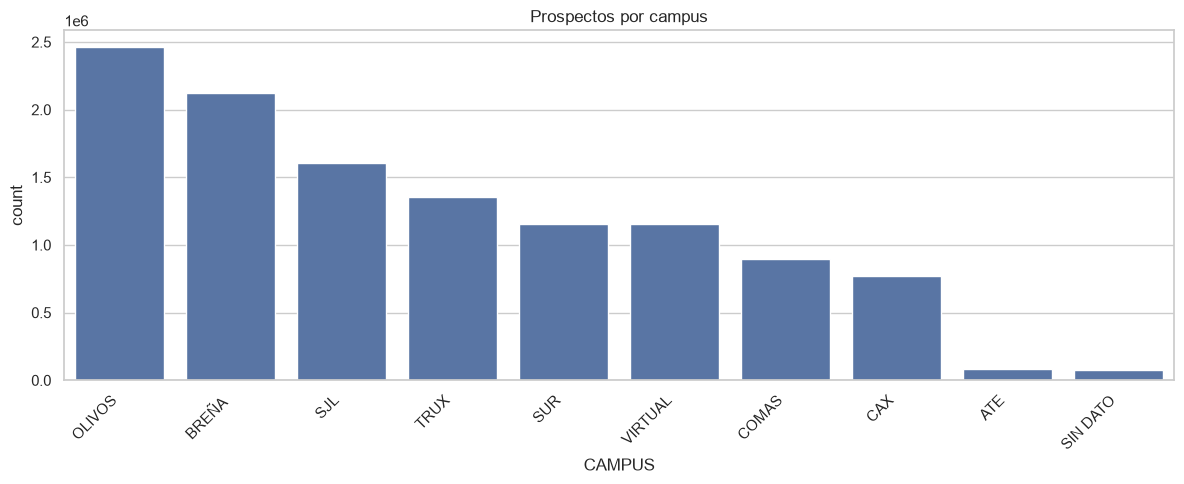

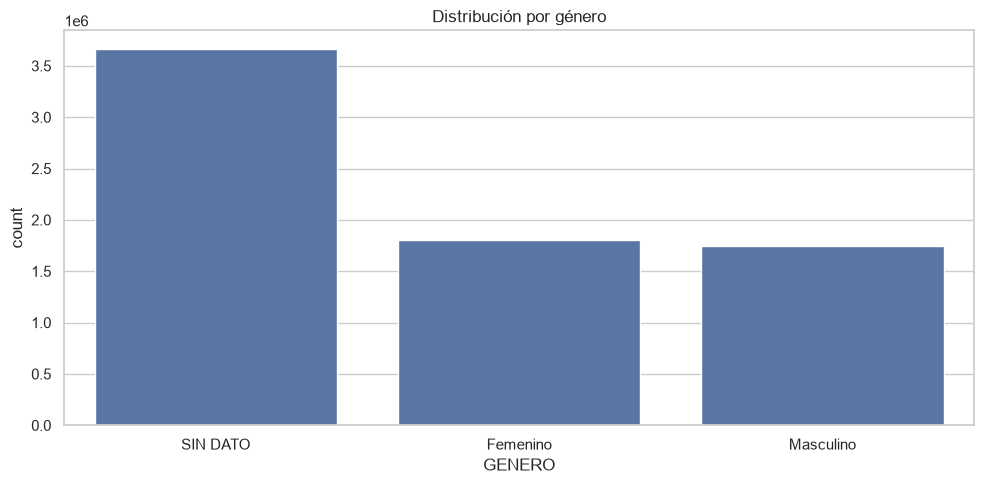

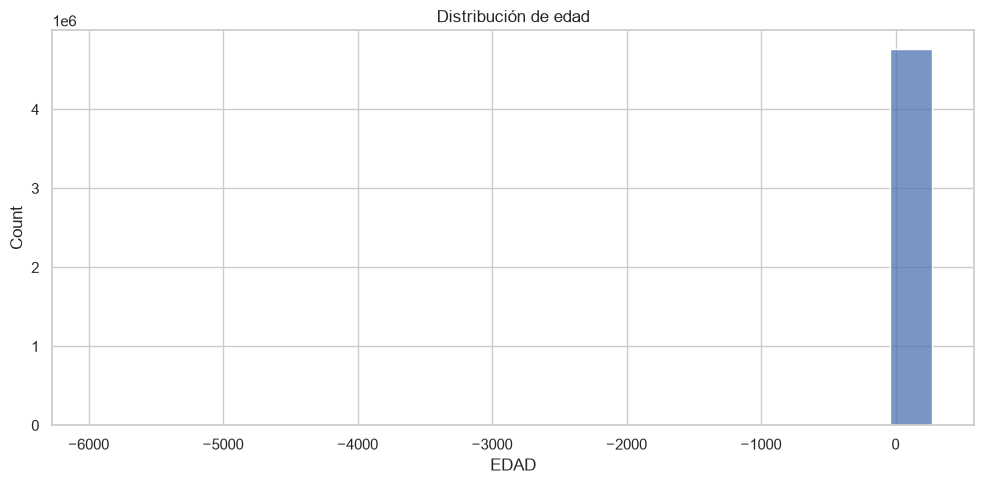

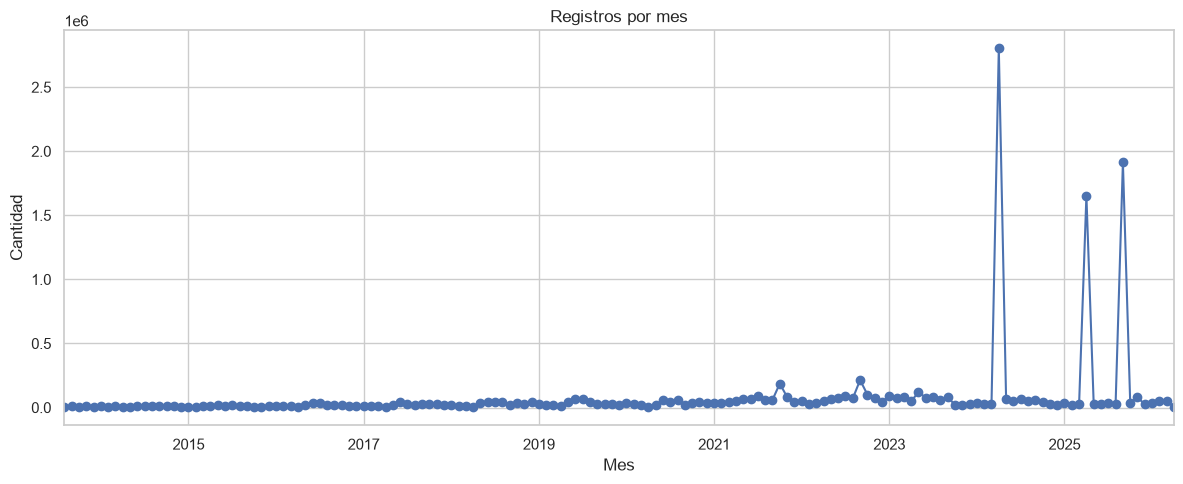

In [8]:
# Estadísticas generales
print("\nResumen estadístico para variables numéricas:\n")
print(df.describe(include=[np.number]).T)
print("\nResumen de variables categóricas:\n")
print(df.describe(include=[object]).T)

# Columnas recomendadas para análisis exploratorio
categorical_cols = [
    "CAMPAÑA", "BASE_ST", "TIPO_ESTUDIANTE", "CAMPUS", "FUENTE_ORIGEN",
    "CARRERA", "FACULTAD", "COLEGIO_TIPO", "RANGO_EDAD", "RANGO_EGRESO", "GENERO"
]

print("\nConteo de valores en columnas categóricas seleccionadas:\n")
for col in categorical_cols:
    if col in df.columns:
        print(f"--- {col} ---")
        print(df[col].fillna("<NA>").value_counts(dropna=False).head(10).to_string())
        print()

# Visualizaciones básicas
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="CAMPUS", order=df["CAMPUS"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Prospectos por campus")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="GENERO", order=df["GENERO"].value_counts().index)
plt.title("Distribución por género")
plt.tight_layout()
plt.show()

if "EDAD" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df["EDAD"].replace(0, np.nan).dropna(), bins=20)
    plt.title("Distribución de edad")
    plt.tight_layout()
    plt.show()

if "FECHA_REGISTRO" in df.columns:
    plt.figure(figsize=(12, 5))
    df["FECHA_REGISTRO"].dt.to_period("M").value_counts().sort_index().plot(marker="o")
    plt.title("Registros por mes")
    plt.xlabel("Mes")
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.show()